In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
import pyarrow.parquet as pq

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [ ]:
df = pd.read_parquet('../data/Cleaned_Transportation_Data.parquet')

## Route Cause Analysis: What factors need to poor on-time rate?

In [3]:
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

supplier_stats = df.groupby('supplier_name').agg(
    total_trips=('booking_id', 'count'),
    ontime_trips=('ontime', lambda x: (x == 'Yes').sum()),
    median_dist_km=('transportation_distance_km', 'median'),
    median_sla=('planned_eta', 'median'),
    main_shipment_type=('shipment_type', get_mode),
    main_movement=('movement_type', get_mode),
    top_route=('route_name', get_mode),
    top_vehicle=('vehicle_type', get_mode),
    top_material=('material_shipped', get_mode) 
).reset_index()

supplier_stats['ontime_rate_%'] = (supplier_stats['ontime_trips'] / supplier_stats['total_trips']) * 100

filtered_suppliers = supplier_stats[supplier_stats['total_trips'] > 50]

# Worst supplier
bottom_5_suppliers = filtered_suppliers.sort_values(by='ontime_rate_%', ascending=True).head(5)

bottom_5_suppliers['ontime_rate_%'] = bottom_5_suppliers['ontime_rate_%'].round(2)
bottom_5_suppliers['median_dist_km'] = bottom_5_suppliers['median_dist_km'].round(1)

# Best supplier
top_5_suppliers = filtered_suppliers.sort_values(by='ontime_rate_%', ascending=False).head(5)

top_5_suppliers['ontime_rate_%'] = top_5_suppliers['ontime_rate_%'].round(2)
top_5_suppliers['median_dist_km'] = top_5_suppliers['median_dist_km'].round(1)

# Reorder columns
display_cols = [
    'supplier_name', 'total_trips', 'ontime_rate_%', 
    'main_movement', 'main_shipment_type', 'median_dist_km', 'median_sla', 
    'top_route', 'top_vehicle', 'top_material'
]

# Ensure no KeyError if column names differ
print("-- Top 5 worst supplier --")
print(bottom_5_suppliers[display_cols].to_string(index=False))


print("\n-- Top 5 best supplier --")
print(top_5_suppliers[display_cols].to_string(index=False))

-- Top 5 worst supplier --
                supplier_name  total_trips  ontime_rate_% main_movement main_shipment_type  median_dist_km      median_sla                                                              top_route                 top_vehicle top_material
            Rajdhani Roadways           64           0.00    Inter city            Regular          1178.0 1 days 04:19:30                   Shive, pune, maharashtra - Sirohi, Jaipur, Rajasthan 32 FT Single-Axle 7MT - HCV   Auto Parts
    K.Ramachandran Transports           61           1.64    Inter city            Regular            90.0 1 days 07:37:00      Manali, tiruvallur, tamil nadu - Thaiyur, Kanchipuram, Tamil Nadu      40 FT 3XL Trailer 35MT   Auto Parts
                      Unknown          215           2.33    Inter city            Regular           667.0 1 days 06:15:00                  Kollur, medak, telangana - Lakdaram, Medak, Telangana        19 FT Open 7MT - MCV   Auto Parts
            Trans Cargo India    

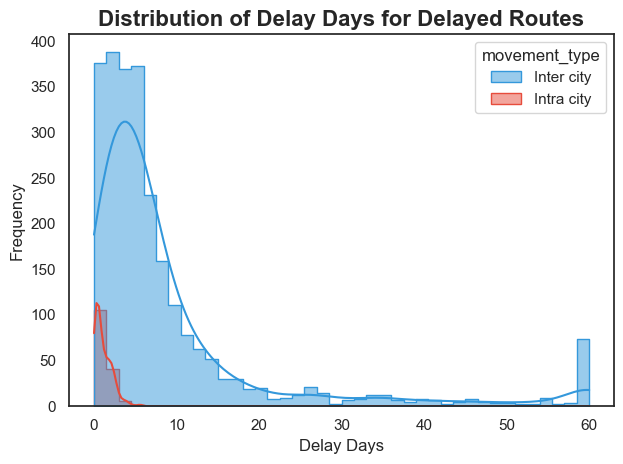

               count         max       min    median       mean        std
movement_type                                                             
Inter city      2558  207.011111  0.008333  5.044792  10.836392  21.870225
Intra city       153    5.563819  0.006250  0.718125   1.126974   1.022645


In [4]:
delayed_df = df[df['delay_time_days'] > 0].copy()

delayed_df['delay_clipped'] = delayed_df['delay_time_days'].clip(upper=60)

sns.set_theme(style='white')

# Histogram of Delay Days Distribution
sns.histplot(data=delayed_df, x='delay_clipped', hue='movement_type', 
             bins=40, kde=True, palette={'Intra city': '#E74C3C', 'Inter city': '#3498DB'},
             alpha=0.5, element='step')

plt.title('Distribution of Delay Days for Delayed Routes', fontsize=16, fontweight='bold')
plt.xlabel('Delay Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print(delayed_df.groupby('movement_type')['delay_time_days'].agg(['count', 'max', 'min', 'median', 'mean', 'std']))

### SLA Problem Analysis

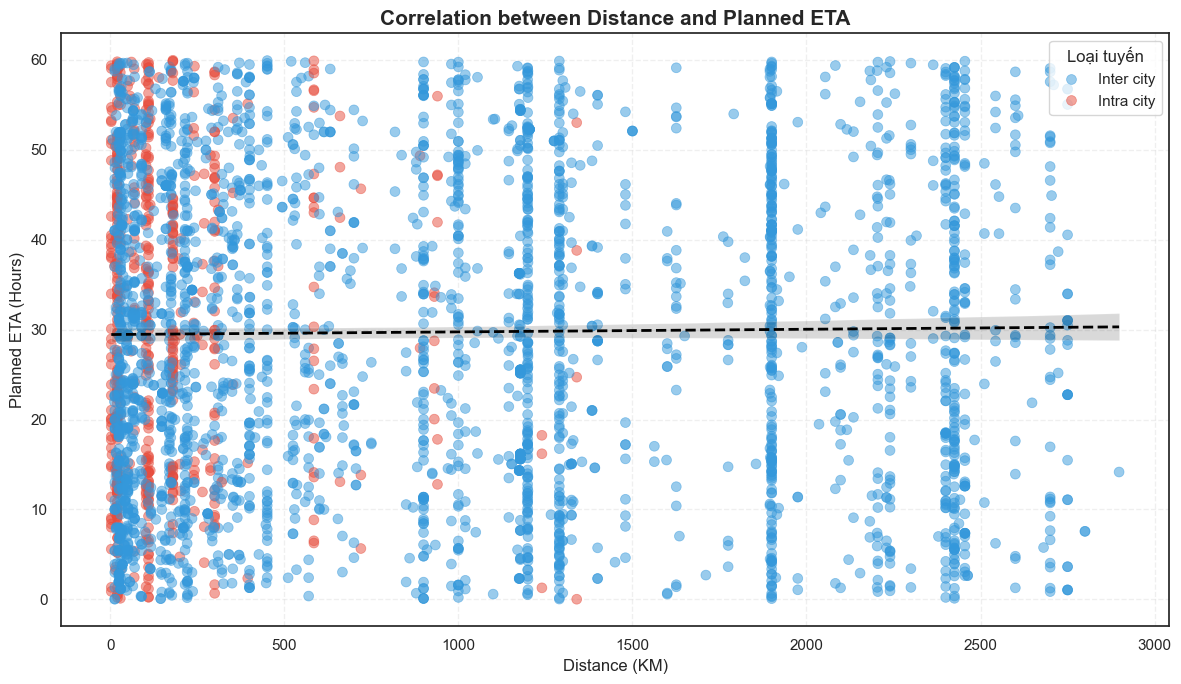

=== Correlation coefficient ===
Pearson coeficient (r) = 0.0144
=> Conclude: Have weak relationship. SLA does NOT seem to be calculated based on transportation distance.


In [6]:
df['planned_eta_hours'] = df['planned_eta'].dt.total_seconds() / 3600

sla_check_df = df[df['planned_eta_hours'] > 0].copy()

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=sla_check_df,
    x='transportation_distance_km',
    y='planned_eta_hours',
    hue='movement_type',
    palette={'Intra city': '#E74C3C', 'Inter city': '#3498DB'},
    alpha=0.5,
    edgecolor=None,
    s=50
)

sns.regplot(
    data=sla_check_df,
    x='transportation_distance_km',
    y='planned_eta_hours',
    scatter=False, 
    color='black',
    line_kws={'linestyle':'--', 'linewidth': 2}
)

# 3. Tùy chỉnh hiển thị
plt.title('Correlation between Distance and Planned ETA', fontsize=15, fontweight='bold')
plt.xlabel('Distance (KM)', fontsize=12)
plt.ylabel('Planned ETA (Hours)', fontsize=12)
plt.legend(title='Loại tuyến', fontsize=11)
plt.grid(axis='both', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# 4. Tính toán và In Hệ số tương quan Pearson
correlation = sla_check_df['transportation_distance_km'].corr(sla_check_df['planned_eta_hours'])

print("=== Correlation coefficient ===")
print(f"Pearson coeficient (r) = {correlation:.4f}")

if abs(correlation) < 0.3:
    print("=> Conclude: Have weak relationship. SLA does NOT seem to be calculated based on transportation distance.")
elif abs(correlation) < 0.7:
    print("=> Conclude: Have moderate relationship.")
else:
    print("=> Conclude: Have strong relationship. SLA has a strong correlation with transportation distance.")

In [7]:
speed_standard_intra = 150  # km per day (Intra-city)
speed_standard_inter = 400  # km per day (Inter-city)

median_dist_intra = df[df['movement_type'] == 'Intra city']['transportation_distance_km'].median()
median_dist_inter = df[df['movement_type'] == 'Inter city']['transportation_distance_km'].median()

buffer_days_intra = 0.5
buffer_days_inter = 1.0 

def calculate_new_sla(row):
    dist = row['transportation_distance_km']
    if pd.isna(dist) or dist < 0: return np.nan
    
    if row['movement_type'] == 'Intra-city':
        transit_time = dist / speed_standard_intra
        return transit_time + buffer_days_intra
    else:
        transit_time = dist / speed_standard_inter
        return transit_time + buffer_days_inter

df['new_sla_days'] = df.apply(calculate_new_sla, axis=1)

# 4. Cập nhật trạng thái On-time mới
df['new_delay_days'] = df['trip_duration'] - df['new_sla_days']
df['new_ontime'] = df['new_delay_days'] <= 0

def print_stats(df_subset, subset_name, speed_std, median_dist):
    total_trips = len(df_subset)
    if total_trips == 0: return
    
    new_ontime_count = df_subset['new_ontime'].sum()
    new_delayed_count = total_trips - new_ontime_count
    
    new_ontime_rate = (new_ontime_count / total_trips) * 100
    new_delayed_rate = (new_delayed_count / total_trips) * 100
    
    old_ontime_count = (df_subset['ontime'] == 'Yes').sum()
    old_ontime_rate = (old_ontime_count / total_trips) * 100
    
    print(f"--- {subset_name.upper()} ---")
    print(f"* Simulation Parameters:")
    print(f"  - Representative Distance (Median): {median_dist:.1f} km")
    print(f"  - Industry Standard Speed: {speed_std} km/day")
    print(f"  - Baseline SLA for Median Dist (min 1 day): {max(median_dist/speed_std, 1.0):.1f} days\n")
    
    print(f"Total Trips: {total_trips}")
    print(f"On-time Rate (OLD): {old_ontime_rate:.2f}% ({old_ontime_count} trips)")
    print(f"On-time Rate (NEW): {new_ontime_rate:.2f}% ({new_ontime_count} trips)")
    print(f"Delayed Rate (NEW): {new_delayed_rate:.2f}% ({new_delayed_count} trips)")
    
    still_delayed = df_subset[df_subset['new_delay_days'] > 0]
    if len(still_delayed) > 0:
        print(f"Average Delay (Median): {still_delayed['new_delay_days'].median():.1f} days")
    print("-" * 45 + "\n")

print_stats(df[df['movement_type'] == 'Intra city'], 'Intra-city Movement', speed_standard_intra, median_dist_intra)
print_stats(df[df['movement_type'] == 'Inter city'], 'Inter-city Movement', speed_standard_inter, median_dist_inter)

total_trips = len(df)
new_ontime_count = df['new_ontime'].sum()
print(f"--- OVERALL SYSTEM PERFORMANCE (NEW SLA) ---")
print(f"System On-time Rate (OLD): {(df['ontime'] == 'Yes').sum() / total_trips * 100:.2f}%")
print(f"System On-time Rate (NEW): {(new_ontime_count / total_trips) * 100:.2f}% ({new_ontime_count} trips)")

--- INTRA-CITY MOVEMENT ---
* Simulation Parameters:
  - Representative Distance (Median): 104.0 km
  - Industry Standard Speed: 150 km/day
  - Baseline SLA for Median Dist (min 1 day): 1.0 days

Total Trips: 593
On-time Rate (OLD): 74.20% (440 trips)
On-time Rate (NEW): 89.54% (531 trips)
Delayed Rate (NEW): 10.46% (62 trips)
Average Delay (Median): 1.0 days
---------------------------------------------

--- INTER-CITY MOVEMENT ---
* Simulation Parameters:
  - Representative Distance (Median): 900.0 km
  - Industry Standard Speed: 400 km/day
  - Baseline SLA for Median Dist (min 1 day): 2.2 days

Total Trips: 2933
On-time Rate (OLD): 12.79% (375 trips)
On-time Rate (NEW): 39.69% (1164 trips)
Delayed Rate (NEW): 60.31% (1769 trips)
Average Delay (Median): 4.7 days
---------------------------------------------

--- OVERALL SYSTEM PERFORMANCE (NEW SLA) ---
System On-time Rate (OLD): 23.11%
System On-time Rate (NEW): 48.07% (1695 trips)


### Fleet and Material Shipping Allocation

In [8]:
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

df['vehicle_type_clean'] = df['vehicle_type'].fillna('Unknown')
delayed_df = df[df['new_delay_days'] > 0].copy()

total_stats = df.groupby('supplier_name').agg(
    total_trips=('booking_id', 'count')
).reset_index()

delayed_base_stats = delayed_df.groupby('supplier_name').agg(
    delayed_trips=('booking_id', 'count'),
    avg_delay_days=('new_delay_days', 'mean'),
    median_delay_days=('new_delay_days', 'median'),
    mainly_movement_type=('movement_type', get_mode)
).reset_index()

total_veh = df.groupby(['supplier_name', 'vehicle_type_clean']).size().reset_index(name='total_veh_trips')

delayed_veh = delayed_df.groupby(['supplier_name', 'vehicle_type_clean']).agg(
    count=('booking_id', 'count'),
    median_dist=('transportation_distance_km', 'median')
).reset_index()

veh_stats = pd.merge(delayed_veh, total_veh, on=['supplier_name', 'vehicle_type_clean'], how='left')
veh_stats['rate_%'] = ((veh_stats['count'] / veh_stats['total_veh_trips']) * 100).round(1)
veh_stats['median_dist'] = veh_stats['median_dist'].round(1)

veh_stats = veh_stats.sort_values(['supplier_name', 'count'], ascending=[True, False])
veh_stats['rank'] = veh_stats.groupby('supplier_name').cumcount() + 1
top3_veh = veh_stats[veh_stats['rank'] <= 3]

fleet_stats = top3_veh.pivot(index='supplier_name', columns='rank', values=['vehicle_type_clean', 'count', 'rate_%', 'median_dist'])
fleet_stats.columns = [f"{'vehicle' if 'vehicle' in col[0] else col[0]}_{col[1]}" for col in fleet_stats.columns]
fleet_stats = fleet_stats.rename(columns=lambda x: x.replace('rate_%_', 'rate_').replace('median_dist_', 'dist_')).reset_index()

delayed_full_stats = pd.merge(delayed_base_stats, fleet_stats, on='supplier_name', how='left')
supplier_breakdown = pd.merge(total_stats, delayed_full_stats, on='supplier_name', how='inner')

supplier_breakdown['delay_rate_%'] = ((supplier_breakdown['delayed_trips'] / supplier_breakdown['total_trips']) * 100).round(2)

supplier_breakdown = supplier_breakdown[supplier_breakdown['total_trips'] > 50]

top_10_delayed = supplier_breakdown.sort_values('delayed_trips', ascending=False).head(10)

top_10_delayed['avg_delay_days'] = top_10_delayed['avg_delay_days'].round(1)
top_10_delayed['median_delay_days'] = top_10_delayed['median_delay_days'].round(1)

display_cols = [
    'supplier_name', 'total_trips', 'delayed_trips', 'delay_rate_%', 
    'avg_delay_days', 'median_delay_days', 'mainly_movement_type',
    'vehicle_1', 'count_1', 'rate_1', 'dist_1',
    'vehicle_2', 'count_2', 'rate_2', 'dist_2',
    'vehicle_3', 'count_3', 'rate_3', 'dist_3'
]

for i in range(1, 4):
    for prefix in ['vehicle_', 'count_', 'rate_', 'dist_']:
        col_name = f"{prefix}{i}"
        if col_name not in top_10_delayed.columns:
            top_10_delayed[col_name] = None

print("\n--- TOP 10 SUPPLIERS BY DELAYED TRIP ---")
print(top_10_delayed[display_cols].to_string(index=False))


--- TOP 10 SUPPLIERS BY DELAYED TRIP ---
                    supplier_name  total_trips  delayed_trips  delay_rate_%  avg_delay_days  median_delay_days mainly_movement_type                                vehicle_1 count_1 rate_1  dist_1                                vehicle_2 count_2 rate_2  dist_2                                 vehicle_3 count_3 rate_3  dist_3
                          Unknown          215            175         81.40            11.4                6.5           Inter city                     19 FT Open 7MT - MCV      61   96.8   667.0                   40 FT 3XL Trailer 35MT      53   88.3    70.0               32 FT Multi-Axle 14MT - HCV      37   60.7  1823.0
  Sunita Carriers Private Limited          159            123         77.36            19.6                5.4           Inter city 40 FT Flat Bed Multi-Axle 27MT - Trailer      55   79.7    78.7                   40 FT 3XL Trailer 35MT      33   63.5   210.0 40 FT Flat Bed Double-Axle 21MT - Trailer      1

--- Fleet Distribution (Volume) ---
vehicle_group  19 FT Open 7MT - MCV  32 FT Multi-Axle 14MT - HCV  \
movement_type                                                      
Inter city                       75                          425   
Intra city                        0                            0   
All                              75                          425   

vehicle_group  32 FT Multi-Axle MXL 18MT  32 FT Single-Axle 7MT - HCV  \
movement_type                                                           
Inter city                            37                          298   
Intra city                             0                            0   
All                                   37                          298   

vehicle_group  40 FT 3XL Trailer 35MT  \
movement_type                           
Inter city                        519   
Intra city                          4   
All                               523   

vehicle_group  40 FT Flat Bed Multi-Axle 27MT - Tra

<Figure size 1200x700 with 0 Axes>

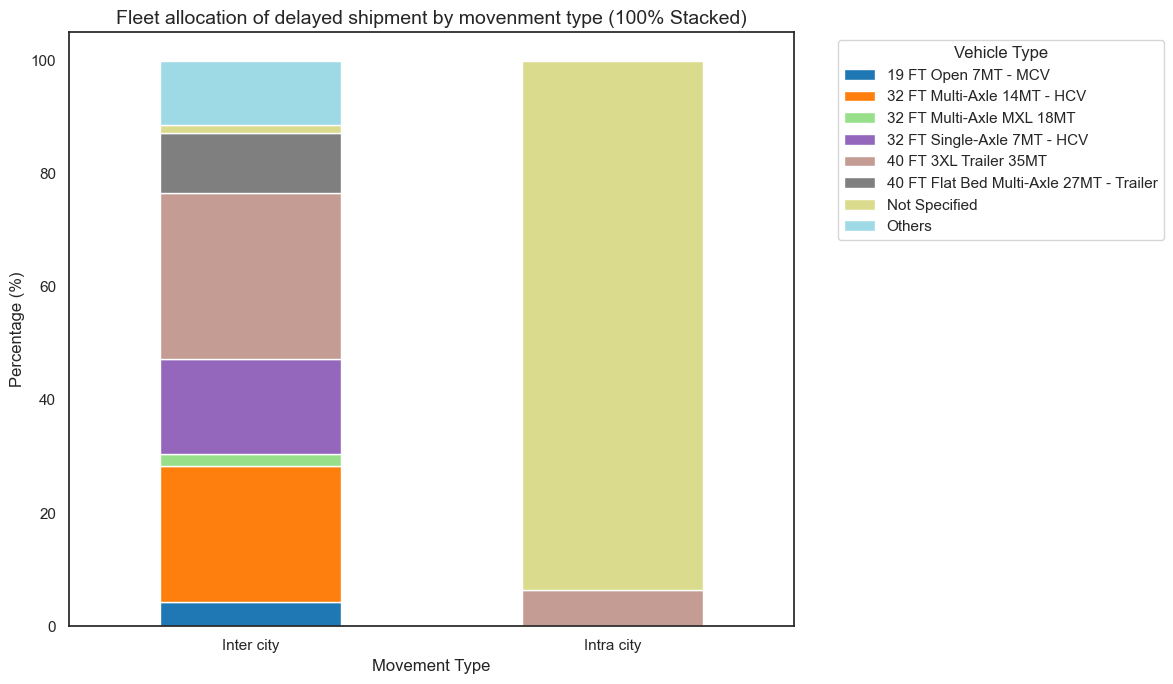

In [9]:
top_vehicles = delayed_df['vehicle_type'].value_counts().nlargest(7).index.tolist()

delayed_df['vehicle_group'] = delayed_df['vehicle_type'].apply(lambda x: x if x in top_vehicles else 'Others')

cross_tab = pd.crosstab(delayed_df['movement_type'], delayed_df['vehicle_group'], margins=True)
print("--- Fleet Distribution (Volume) ---")
print(cross_tab)

cross_tab_pct = pd.crosstab(delayed_df['movement_type'], delayed_df['vehicle_group'], normalize='index') * 100

plt.figure(figsize=(12, 7))
cross_tab_pct.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12, 7))
plt.title('Fleet allocation of delayed shipment by movenment type (100% Stacked)', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Movement Type', fontsize=12)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

print("\n--- Fleet Distribution ---")
for cat in ['Intra city', 'Inter city']:
    subset = delayed_df[delayed_df['movement_type'] == cat]
    top_veh = subset['vehicle_type'].value_counts().head(5)
    print(f"\n[{cat}] (Tổng: {len(subset)} chuyến)")
    print(top_veh.to_string())

--- PHÂN BỔ LOẠI XE THEO TOP 10 HÀNG HÓA ---
vehicle_group      19 FT Open 7MT - MCV  20 FT SXL Container  32 FT Multi-Axle 14MT - HCV  32 FT Single-Axle 7MT - HCV  40 FT 3XL Trailer 35MT  40 FT Flat Bed Double-Axle 21MT - Trailer  40 FT Flat Bed Multi-Axle 27MT - Trailer  Other
material_shipped                                                                                                                                                                                                                          
Auto Parts                           36                   16                          143                           99                     199                                         16                                        83     82
Empty Trays                           5                    2                           33                           28                      27                                          4                                        13     14
Grs Starter    

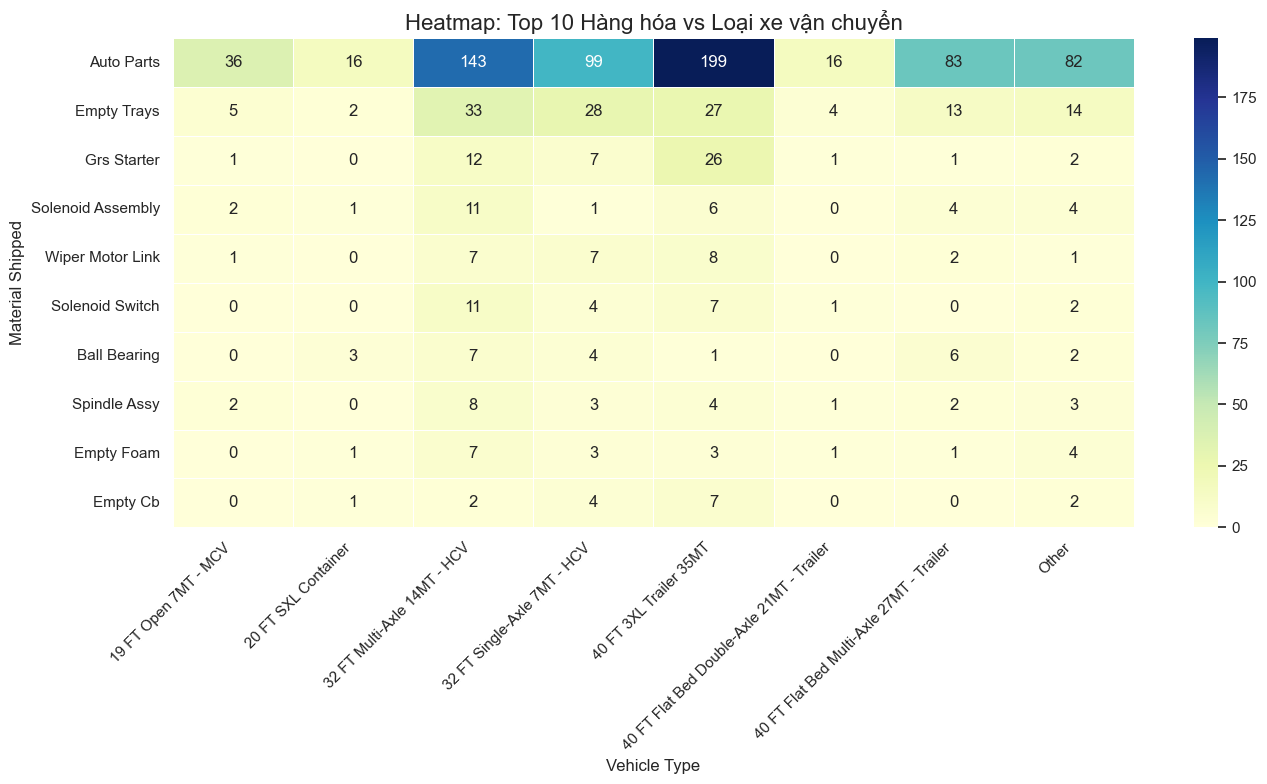

In [10]:
top_materials = delayed_df['material_shipped'].value_counts().nlargest(10).index.tolist()

df_top_mat = delayed_df[delayed_df['material_shipped'].isin(top_materials)].copy()

top_vehicles = df_top_mat['vehicle_type'].value_counts().nlargest(7).index.tolist()
df_top_mat['vehicle_group'] = df_top_mat['vehicle_type'].apply(lambda x: x if x in top_vehicles else 'Other')

pivot_mat_veh = pd.crosstab(df_top_mat['material_shipped'], df_top_mat['vehicle_group'])

pivot_mat_veh['Total'] = pivot_mat_veh.sum(axis=1)
pivot_mat_veh = pivot_mat_veh.sort_values('Total', ascending=False).drop(columns='Total')

print("--- PHÂN BỔ LOẠI XE THEO TOP 10 HÀNG HÓA ---")
print(pivot_mat_veh.to_string())

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_mat_veh, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap: Top 10 Hàng hóa vs Loại xe vận chuyển', fontsize=16)
plt.ylabel('Material Shipped', fontsize=12)
plt.xlabel('Vehicle Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('material_vehicle_heatmap.png')

### Movement Type

In [11]:
from scipy.stats import chi2_contingency

df['ontime_numeric'] = df['ontime'].map({'Yes': 1, 'No': 0})

contingency_table = pd.crosstab(df['shipment_type'], df['ontime'])
print("--- CONTINGENCY TABLE ---")
print(contingency_table)

# 2. Tính Tỷ lệ trễ hạn (Delay Rate) cho từng loại Shipment để có cái nhìn trực quan
delay_rate = df.groupby('shipment_type')['ontime_numeric'].mean() * 100
print("\n--- DELAY RATE BY SHIPMENT TYPE (%) ---")
print(delay_rate.round(2))

# 3. Chạy kiểm định Chi-Square
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# 4. Kết luận thống kê (với mức ý nghĩa alpha = 0.05)
alpha = 0.05
print("\n--- CONCLUSION ---")
if p_val < alpha:
    print("Reject Null Hypothesis (Bác bỏ H0).")
    print("Có mối liên hệ MANG TÍNH THỐNG KÊ giữa Shipment Type và việc trễ hạn.")
else:
    print("Fail to Reject Null Hypothesis (Chấp nhận H0).")
    print("KHÔNG có bằng chứng thống kê cho thấy Shipment Type ảnh hưởng đến việc trễ hạn.")

--- CONTINGENCY TABLE ---
ontime           No  Yes
shipment_type           
Market           31   27
Regular        2680  788

--- DELAY RATE BY SHIPMENT TYPE (%) ---
shipment_type
Market     46.55
Regular    22.72
Name: ontime_numeric, dtype: float64

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 16.9118
P-value: 3.9158e-05

--- CONCLUSION ---
Reject Null Hypothesis (Bác bỏ H0).
Có mối liên hệ MANG TÍNH THỐNG KÊ giữa Shipment Type và việc trễ hạn.


In [12]:
pd.crosstab(df['shipment_type'], df['movement_type'], normalize='index') * 100

movement_type,Inter city,Intra city
shipment_type,,
Market,72.413793,27.586207
Regular,83.362168,16.637832


In [13]:
if 'is_delayed' not in df.columns:
    df['is_delayed'] = df['new_delay_days'] > 0

# Chỉ Inter-city
inter = df[df['movement_type'] == 'Inter city']
print("\n--- INTER-CITY CONTINGENCY TABLE ---")
inter_contigency = pd.crosstab(inter['shipment_type'], inter['ontime'])
print(inter_contigency)

chi2_stat, p_val, dof, expected = chi2_contingency(inter_contigency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Chỉ Intra-city  
intra = df[df['movement_type'] == 'Intra city']
print("\n--- INTRA-CITY CONTINGENCY TABLE ---")
intra_contingency = pd.crosstab(intra['shipment_type'], intra['ontime'])
print(intra_contingency)

chi2_stat, p_val, dof, expected = chi2_contingency(intra_contingency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")


--- INTER-CITY CONTINGENCY TABLE ---
ontime           No  Yes
shipment_type           
Market           25   17
Regular        2533  358

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 26.8351
P-value: 2.2158e-07

--- INTRA-CITY CONTINGENCY TABLE ---
ontime          No  Yes
shipment_type          
Market           6   10
Regular        147  430

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 0.6314
P-value: 4.2683e-01


In [19]:
from statsmodels.stats.proportion import proportion_confint
low, high = proportion_confint(25, 42, alpha=0.05, method='wilson')
print(f"Market inter-city delay rate CI: {low*100:.1f}% to {high*100:.1f}%")   

low, high = proportion_confint(2533, 2819, alpha=0.05, method='wilson')
print(f"Regular inter-city delay rate CI: {low*100:.1f}% to {high*100:.1f}%")

Market inter-city delay rate CI: 44.5% to 73.0%
Regular inter-city delay rate CI: 88.7% to 90.9%


In [15]:
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

# Tạo cột is_delayed nếu chưa có
if 'is_delayed' not in df.columns:
    df['is_delayed'] = df['new_delay_days'] > 0

# 1. Lọc tập dữ liệu: Chỉ lấy Regular và Inter-city
target_df = df[(df['shipment_type'] == 'Regular') & (df['movement_type'] == 'Inter city')].copy()

# 2. Thống kê tổng quan các attribute theo nhà cung cấp
regular_inter_stats = target_df.groupby('supplier_name').agg(
    total_trips=('booking_id', 'count'),
    delayed_trips=('is_delayed', 'sum'),
    median_dist_km=('transportation_distance_km', 'median'),
    top_vehicle=('vehicle_type', get_mode),
    top_material=('material_shipped', get_mode)
).reset_index()

# 3. Tính tỷ lệ trễ hạn
regular_inter_stats['delay_rate_%'] = ((regular_inter_stats['delayed_trips'] / regular_inter_stats['total_trips']) * 100).round(1)

# 4. Tính số ngày trễ trung vị (chỉ tính trên các chuyến thực sự bị trễ)
delayed_only = target_df[target_df['is_delayed'] == True].groupby('supplier_name').agg(
    median_delay_days=('new_delay_days', 'median')
).reset_index()

# 5. Nối dữ liệu và làm sạch
final_stats = pd.merge(regular_inter_stats, delayed_only, on='supplier_name', how='left')
final_stats['median_delay_days'] = final_stats['median_delay_days'].round(1).fillna(0)
final_stats['median_dist_km'] = final_stats['median_dist_km'].round(1)

# Lọc bỏ các nhà xe có quá ít chuyến (<50 chuyến) để tránh nhiễu tỷ lệ %
final_stats = final_stats[final_stats['total_trips'] >= 50]

# Sắp xếp theo số lượng chuyến trễ giảm dần
final_stats = final_stats.sort_values(by=['delayed_trips', 'delay_rate_%'], ascending=[False, False])

# Cấu hình hiển thị
display_cols = [
    'supplier_name', 'total_trips', 'delayed_trips', 'delay_rate_%', 
    'median_delay_days', 'median_dist_km', 'top_vehicle', 'top_material'
]

print("\n--- ATTRIBUTES OF 'REGULAR' SUPPLIERS ON 'INTER-CITY' ROUTES ---")
print(final_stats[display_cols].to_string(index=False))


--- ATTRIBUTES OF 'REGULAR' SUPPLIERS ON 'INTER-CITY' ROUTES ---
                      supplier_name  total_trips  delayed_trips  delay_rate_%  median_delay_days  median_dist_km                              top_vehicle top_material
                            Unknown          215            175          81.4                6.5           667.0                     19 FT Open 7MT - MCV   Auto Parts
    Sunita Carriers Private Limited          158            123          77.8                5.4           210.0 40 FT Flat Bed Multi-Axle 27MT - Trailer   Auto Parts
             Ekta Transport Company          237            105          44.3                4.5          1900.0              32 FT Multi-Axle 14MT - HCV   Auto Parts
                      Krc Logistics          161             98          60.9                2.8          1199.0              32 FT Multi-Axle 14MT - HCV   Auto Parts
                  Trans Cargo India          195             88          45.1                7.2   

In [20]:
mismatch_suppliers = [
    'A P R Trailler Service',
    'K.Ramachandran Transports',
    'Baba Lingaraj Enterprises Pvt Ltd',
    'Rajdhani Roadways',
    'Sunita Carriers Private Limited',
    'As Logistics',
    'Shri Ganesh Traders And Transporter'
]

# Tạo cột is_delayed nếu chưa có
if 'is_delayed' not in df.columns:
    df['is_delayed'] = df['new_delay_days'] > 0

# 1. Lọc tập dữ liệu cơ sở: Inter-city
inter_city_df = df[df['movement_type'] == 'Inter city'].copy()

# 2. Làm sạch dữ liệu:
# Loại bỏ các giao dịch thuộc nhóm Regular bị lỗi Mismatch. Giữ nguyên toàn bộ Market.
clean_df = inter_city_df[~((inter_city_df['shipment_type'] == 'Regular') & 
                           (inter_city_df['supplier_name'].isin(mismatch_suppliers)))]

# 3. Xây dựng lại Contingency Table
contingency_table_clean = pd.crosstab(clean_df['shipment_type'], clean_df['is_delayed'])

# 4. Tính toán Tỷ lệ trễ mới
delay_rate_clean = clean_df.groupby('shipment_type')['is_delayed'].mean() * 100

# 5. Kiểm định Chi-Square trên tập dữ liệu đã làm sạch
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table_clean)

# In kết quả
print("--- CLEANED INTER-CITY CONTINGENCY TABLE ---")
print(contingency_table_clean)

print("\n--- NEW DELAY RATE (%) ---")
print(delay_rate_clean.round(1))

print("\n--- NEW CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha:
    print("Kết luận: Vẫn có sự khác biệt thống kê giữa Market và Regular (Cleaned).")
else:
    print("Kết luận: KHÔNG CÒN sự khác biệt thống kê. Giả thuyết của bạn đã đúng.")

--- CLEANED INTER-CITY CONTINGENCY TABLE ---
is_delayed     False  True 
shipment_type              
Market            28     14
Regular         1044   1245

--- NEW DELAY RATE (%) ---
shipment_type
Market     33.3
Regular    54.4
Name: is_delayed, dtype: float64

--- NEW CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 6.5391
P-value: 1.0553e-02
Kết luận: Vẫn có sự khác biệt thống kê giữa Market và Regular (Cleaned).


In [16]:
# Chi Short-movement
short = df[df['distance_category'] == 'Short (<250 km)']
print("\n--- SHORT MOVEMENT CONTINGENCY TABLE ---")
short_contigency = pd.crosstab(short['shipment_type'], short['ontime'])
print(short_contigency)

chi2_stat, p_val, dof, expected = chi2_contingency(short_contigency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Chi Medium-movement
medium = df[df['distance_category'] == 'Medium (250-500 km)']
print("\n--- MEDIUM MOVEMENT CONTINGENCY TABLE ---")
medium_contigency = pd.crosstab(medium['shipment_type'], medium['ontime'])
print(medium_contigency)

chi2_stat, p_val, dof, expected = chi2_contingency(medium_contigency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Chi Long-movement
long = df[df['distance_category'] == 'Long (500-1000 km)']
print("\n--- LONG MOVEMENT CONTINGENCY TABLE ---")
long_contigency = pd.crosstab(long['shipment_type'], long['ontime'])
print(long_contigency)

chi2_stat, p_val, dof, expected = chi2_contingency(long_contigency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Chi Very-long
very_long = df[df['distance_category'] == 'Very Long (>1000 km)']
print("\n--- VERY LONG MOVEMENT CONTINGENCY TABLE ---")
very_long_contigency = pd.crosstab(very_long['shipment_type'], very_long['ontime'])
print(very_long_contigency)

chi2_stat, p_val, dof, expected = chi2_contingency(very_long_contigency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")


--- SHORT MOVEMENT CONTINGENCY TABLE ---
ontime          No  Yes
shipment_type          
Market           0    1
Regular        866  547

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 0.0533
P-value: 8.1740e-01

--- MEDIUM MOVEMENT CONTINGENCY TABLE ---
ontime          No  Yes
shipment_type          
Market          20   20
Regular        239   93

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 7.1542
P-value: 7.4787e-03

--- LONG MOVEMENT CONTINGENCY TABLE ---
ontime          No  Yes
shipment_type          
Market           3    3
Regular        316   86

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 1.4073
P-value: 2.3551e-01

--- VERY LONG MOVEMENT CONTINGENCY TABLE ---
ontime           No  Yes
shipment_type           
Market            8    3
Regular        1259   62

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 7.6114
P-value: 5.8002e-03
